Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pk
import os

In [ ]:
## mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## loading data
games_details = pd.read_csv('/content/drive/MyDrive/ml_project/games_details.csv')

<ipython-input-3-de8965657762>:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv('/content/drive/MyDrive/ml_project/games_details.csv')


In [ ]:
games_details

,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,...,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,22200477,1610612759,SAS,San Antonio,1629641,Romeo Langford,Romeo,F,NaN,18:06,...,1.0,1.0,2.0,0.0,1.0,0.0,2.0,5.0,2.0,-2.0
1,22200477,1610612759,SAS,San Antonio,1631110,Jeremy Sochan,Jeremy,F,NaN,31:01,...,6.0,3.0,9.0,6.0,1.0,0.0,2.0,1.0,23.0,-14.0
2,22200477,1610612759,SAS,San Antonio,1627751,Jakob Poeltl,Jakob,C,NaN,21:42,...,1.0,3.0,4.0,1.0,1.0,0.0,2.0,4.0,13.0,-4.0
3,22200477,1610612759,SAS,San Antonio,1630170,Devin Vassell,Devin,G,NaN,30:20,...,0.0,9.0,9.0,5.0,3.0,0.0,2.0,1.0,10.0,-18.0
4,22200477,1610612759,SAS,San Antonio,1630200,Tre Jones,Tre,G,NaN,27:44,...,0.0,2.0,2.0,3.0,0.0,0.0,2.0,2.0,19.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668623,11200005,1610612743,DEN,Denver,202706,Jordan Hamilton,NaN,NaN,NaN,19,...,0.0,2.0,2.0,0.0,2.0,0.0,1.0,3.0,17.0,NaN
668624,11200005,1610612743,DEN,Denver,202702,Kenneth Faried,NaN,NaN,NaN,23,...,1.0,0.0,1.0,1.0,1.0,0.0,3.0,3.0,18.0,NaN
668625,11200005,1610612743,DEN,Denver,201585,Kosta Koufos,NaN,NaN,NaN,15,...,3.0,5.0,8.0,0.0,1.0,0.0,0.0,3.0,6.0,NaN
668626,11200005,1610612743,DEN,Denver,202389,Timofey Mozgov,NaN,NaN,NaN,19,...,1.0,2.0,3.0,1.0,0.0,0.0,4.0,2.0,2.0,NaN


In [ ]:
games_details.columns

Index(['GAME_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_CITY', 'PLAYER_ID',
       'PLAYER_NAME', 'NICKNAME', 'START_POSITION', 'COMMENT', 'MIN', 'FGM',
       'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
       'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'PTS',
       'PLUS_MINUS'],
      dtype='object')

Removing useless columns:
- GAME_ID
- TEAM_ID
- TEAM_ABBREVIATION
- TEAM_CITY
- PLAYER_ID
- PLAYER_NAME
- NICKNAME
- START POSITION
- COMMENT

These are all useless cause contain data that refers to specific details about identification.

In [ ]:
## removing above columns
data = games_details.drop(['GAME_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_CITY', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'START_POSITION', 'COMMENT'], axis=1)

The PTS column contains in its computation also the FGM, so this last one can be thrown away. Also, I need to modify the MIN column to obtain the minutes in a standard format

In [ ]:
data['MIN'] = data['MIN'].astype(str)

In [ ]:
## removing FGM column
data = data.drop('FGM', axis=1)

KeyError: "['FGM'] not found in axis"

In [ ]:
## modifying the MIN column to have a standard format for the minutes. To do so, I need to convert the numbers after the ":" symbol such that they are divided by 60 since represent the seconds
for i in range(len(data['MIN'])):
  if (":" in data['MIN'][i]):
    data['MIN'][i] = float(data['MIN'][i].split(":")[0]) + float(data['MIN'][i].split(":")[1])/60

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['MIN'][i] = float(data['MIN'][i].split(":")[0]) + float(data['MIN'][i].split(":")[1])/60
<ipython-input-28-9c0295909570>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['MIN'][i] = float(data['MIN'][i].split(":")[0]) + float(data['MIN'][i].split(":")[1])/60
<ipython-input-28-9c0295909570>:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, 

In [ ]:
## dropping rows with NAs
data = data[data['PLUS_MINUS'].isna() == False]


Start from here

In [ ]:
## import data from drive
data = pd.read_csv('/content/drive/MyDrive/ml_project/games_details_preprocessed.csv')

In [ ]:
data

,MIN,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,18.100000,1.0,1.000,0.0,0.0,0.000,0.0,0.0,0.0,1.0,1.0,2.0,0.0,1.0,0.0,2.0,5.0,2.0,-2.0
1,31.016667,14.0,0.500,2.0,4.0,0.500,7.0,10.0,0.7,6.0,3.0,9.0,6.0,1.0,0.0,2.0,1.0,23.0,-14.0
2,21.700000,9.0,0.667,0.0,0.0,0.000,1.0,1.0,1.0,1.0,3.0,4.0,1.0,1.0,0.0,2.0,4.0,13.0,-4.0
3,30.333333,13.0,0.308,1.0,6.0,0.167,1.0,1.0,1.0,0.0,9.0,9.0,5.0,3.0,0.0,2.0,1.0,10.0,-18.0
4,27.733333,12.0,0.583,1.0,3.0,0.333,4.0,4.0,1.0,0.0,2.0,2.0,3.0,0.0,0.0,2.0,2.0,19.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665964,17.700000,5.0,0.200,0.0,1.0,0.000,0.0,0.0,0.0,0.0,4.0,4.0,1.0,0.0,0.0,3.0,0.0,2.0,2.0
665965,14.883333,4.0,0.500,0.0,0.0,0.000,1.0,2.0,0.5,0.0,2.0,2.0,0.0,1.0,1.0,0.0,2.0,5.0,4.0
665966,16.183333,5.0,0.600,2.0,4.0,0.500,2.0,4.0,0.5,1.0,2.0,3.0,1.0,0.0,1.0,0.0,2.0,10.0,-9.0
665967,12.233333,2.0,0.500,0.0,1.0,0.000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,-11.0


<Axes: >

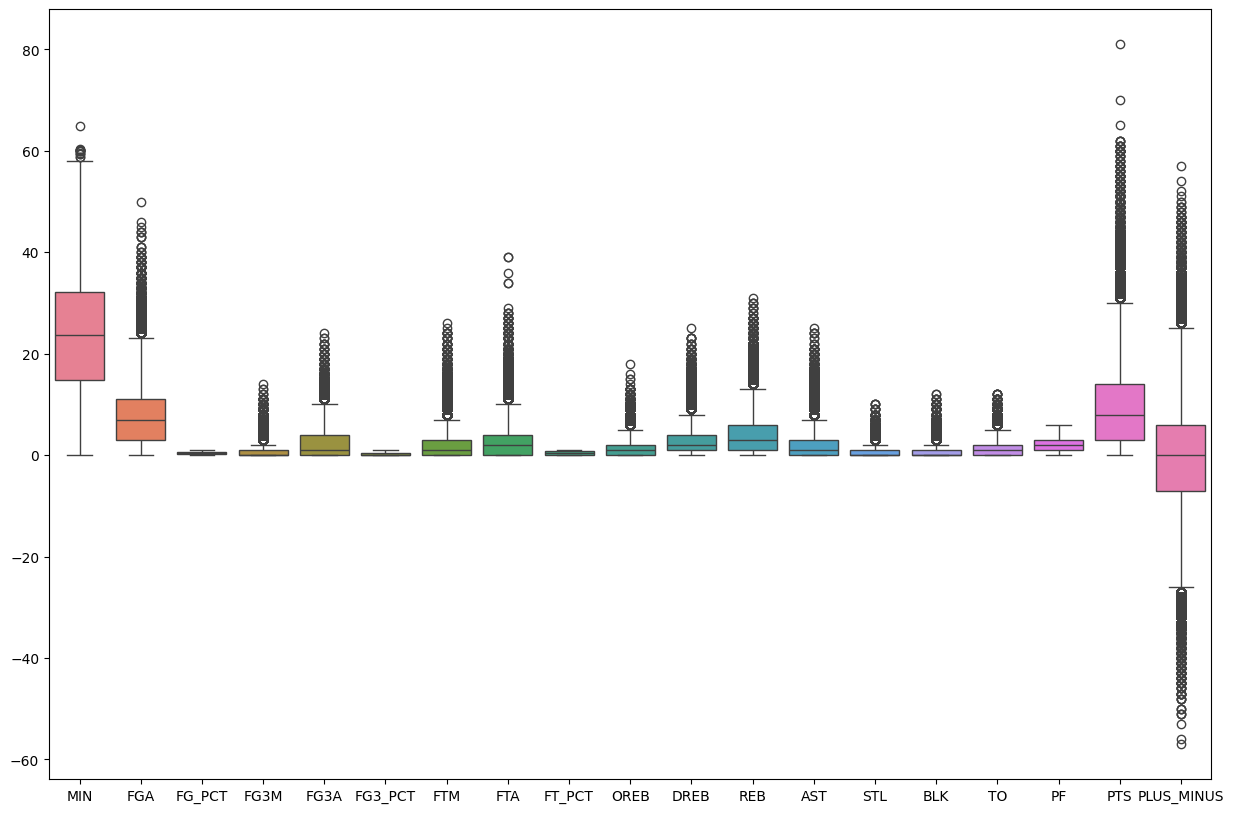

In [ ]:
## plotting boxplots
plt.figure(figsize=(15,10))
sns.boxplot(data=data)

<Axes: >

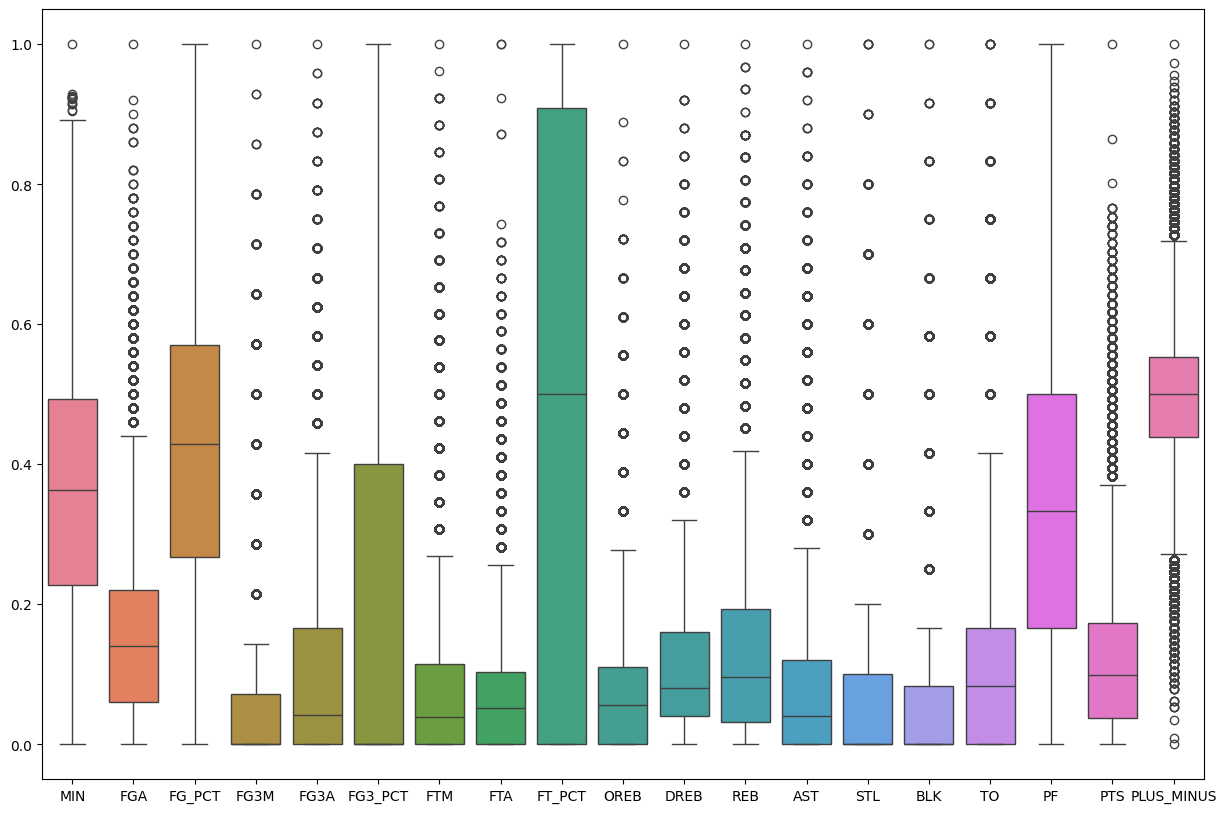

In [ ]:
## standardizing the data with minmax scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_minmax_scaled = scaler.fit_transform(data)
data_minmax_scaled = pd.DataFrame(data_minmax_scaled, columns=data.columns)

## plotting again data
plt.figure(figsize=(15,10))
sns.boxplot(data=data_minmax_scaled)

<Axes: >

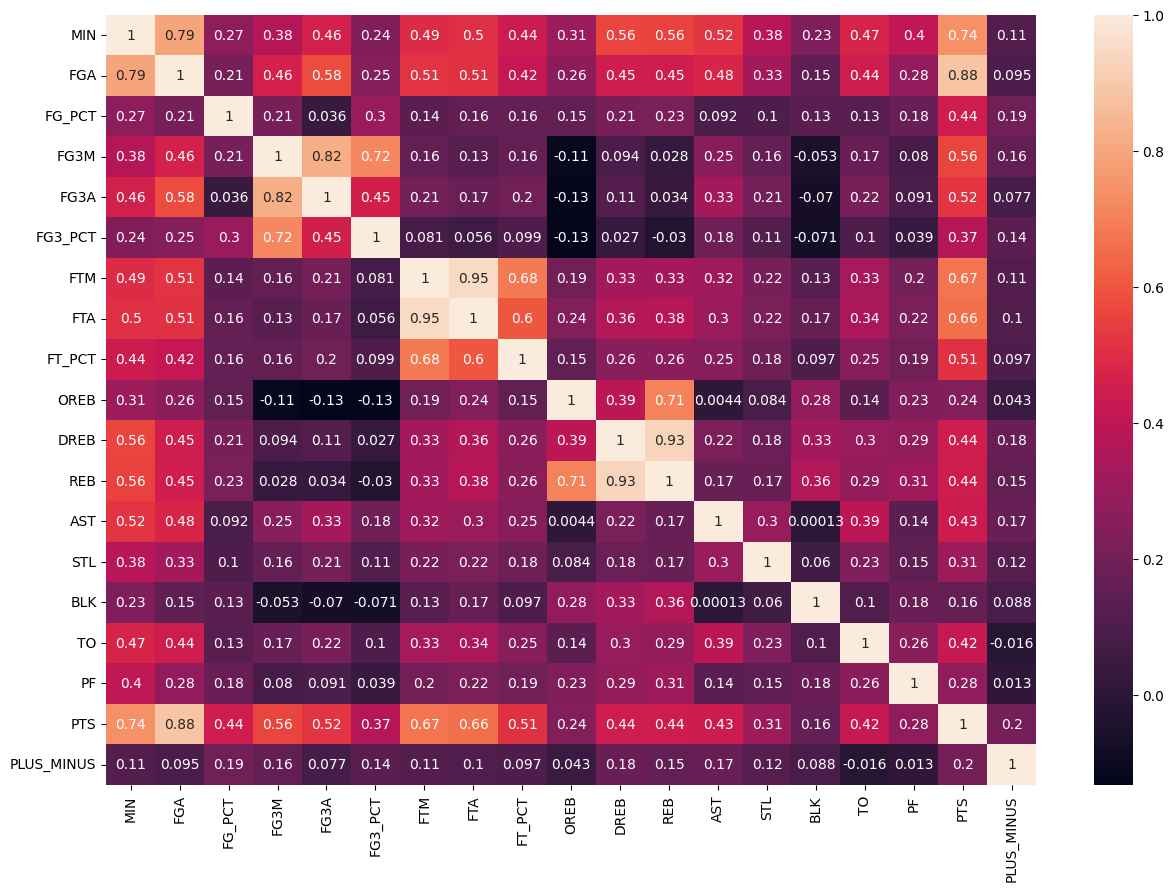

In [ ]:
## correlation
corr = data_minmax_scaled.corr()

## plotting
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True)

Creating train and test data

In [ ]:
## Split the data into train and test set
from sklearn.model_selection import train_test_split

y = data_minmax_scaled['PLUS_MINUS']
x = data_minmax_scaled.drop('PLUS_MINUS', axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
## using linear regression and obtain score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

lr_pred = lin_reg.predict(x_test)
mse_lr = mean_squared_error(y_test, lr_pred)
print(mse_lr)


0.007454989171403437


<Axes: xlabel='PLUS_MINUS', ylabel='Count'>

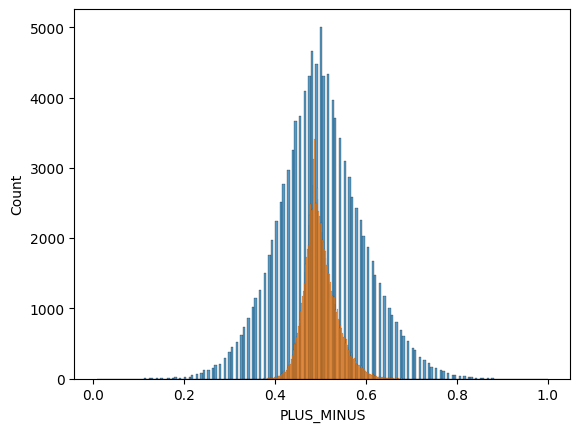

In [ ]:
sns.histplot(y_test)
sns.histplot(lr_pred)

In [ ]:
## splitting initial data
from sklearn.model_selection import train_test_split

y_raw = data['PLUS_MINUS']
x_raw = data.drop('PLUS_MINUS', axis = 1)
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(x_raw, y_raw, test_size = 0.2, random_state = 42)

In [ ]:
## reusing linear_regression with initial data
lin_reg = LinearRegression()
lin_reg.fit(x_train_raw, y_train_raw)

lr_pred = lin_reg.predict(x_test_raw)
r_2 = r2_score(y_test_raw, lr_pred)
mse = mean_squared_error(y_test_raw, lr_pred)
print(r_2)
print(mse)

0.14418940744711028
96.88503927155908


With linear regression there is no evidence in normalising the data

In [ ]:
## using random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)

## obtaining the neg_mean_squared_error
from sklearn.metrics import mean_squared_error
rf_pred = rf.predict(x_test)
mse_rf = mean_squared_error(y_test, rf_pred)
print(mse_rf)

0.007735869044186504


<Axes: xlabel='PLUS_MINUS', ylabel='Count'>

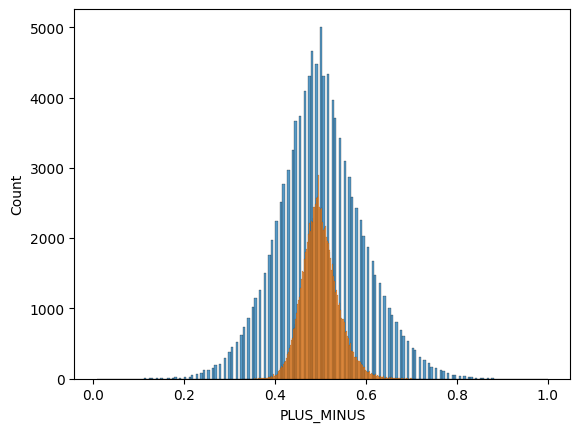

In [ ]:
## plotting distribution of y_test
sns.histplot(y_test)
sns.histplot(rf_pred)

In [ ]:
## importing random_forest_model.pkl from drive
with open('/content/drive/MyDrive/ml_project/rf_model.pkl', 'rb') as f:
  rf_model = pk.load(f)


In [ ]:
## scatterplot of y_test
plt.scatter(y_test, rf_pred, alpha = 0.1)
# adding y=x line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')

## axes
plt.xlabel('y_test')
plt.ylabel('rf_pred')

NameError: name 'rf_pred' is not defined

The model underestimates the real values for larger values of y_test

Text(0, 0.5, 'lr_pred')

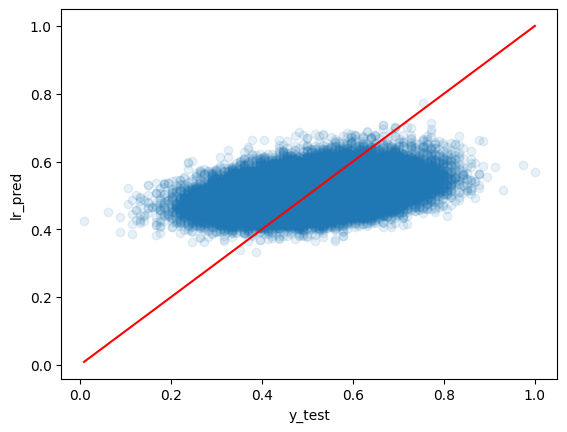

In [ ]:
## scatterplot of y_test
plt.scatter(y_test, lr_pred, alpha = 0.1)
# adding y=x line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')

## axes
plt.xlabel('y_test')
plt.ylabel('lr_pred')

Text(0, 0.5, 'residuals')

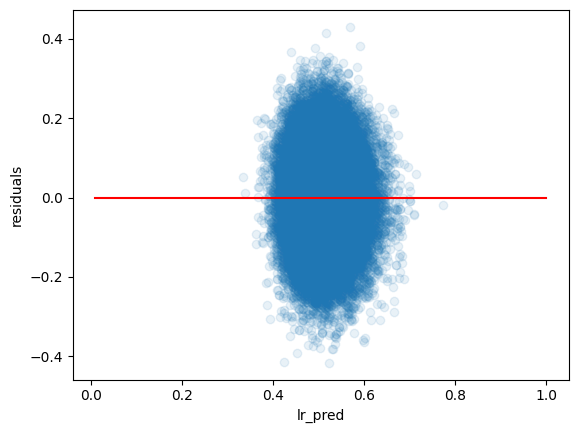

In [ ]:
## lr residuals plot
plt.scatter(lr_pred, y_test - lr_pred, alpha = 0.1)
# adding y=0 line
plt.plot([min(y_test), max(y_test)], [0, 0], color='red')

## axes
plt.xlabel('lr_pred')
plt.ylabel('residuals')

In [ ]:
## using decision trees
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)
mse_dt = mean_squared_error(y_test, dt_pred)
print(mse_dt)

0.015949857105559496


Text(0, 0.5, 'dt_pred')

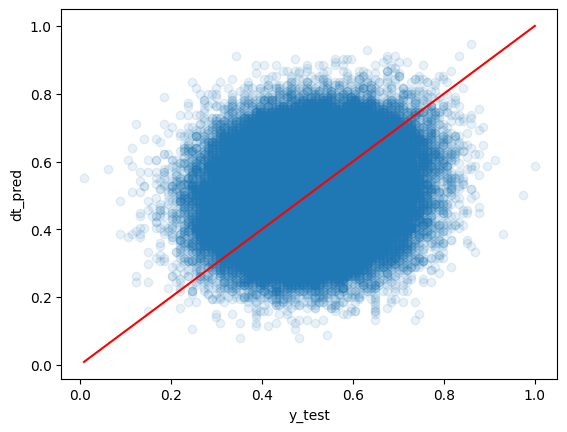

In [ ]:
## scatterplot of y_test
plt.scatter(y_test, dt_pred, alpha = 0.1)
# adding y=x line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')

## axes
plt.xlabel('y_test')
plt.ylabel('dt_pred')

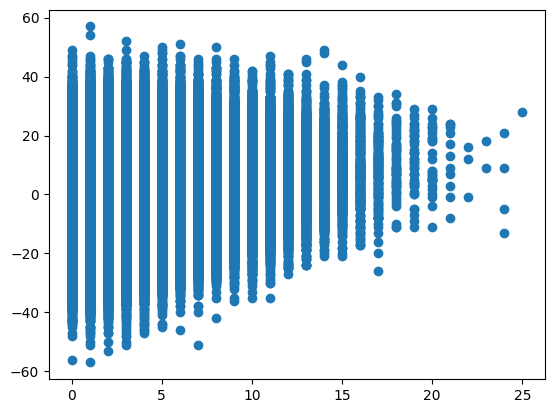

In [ ]:
plt.scatter(x = data['AST'],y = data['PLUS_MINUS'])

Trying a different approach: use a little part of the dataset to preanalyse the data and infer something I can then check in the big picture.
To note that my doubt in the process is still there, that is, one cannot well estimate the plus/minus only with single player's data. To fully caputre the label's variability, one must take into consideration how other players played and this is not always possible since the detailed history of the games is not available.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pk
import os

In [ ]:
## mounting drive
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/ml_project/games_details_preprocessed.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## dropping rows with NAs
data = data[data['PLUS_MINUS'].isna() == False]

In [ ]:
## standardizing and normalising data
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
data_standard_scaled = standard_scaler.fit_transform(data)
data_standard_scaled = pd.DataFrame(data_standard_scaled, columns=data.columns)
min_max_scaler = MinMaxScaler()
data_minmax_scaled = min_max_scaler.fit_transform(data)
data_minmax_scaled = pd.DataFrame(data_minmax_scaled, columns=data.columns)

In [ ]:
## checkiing for NaNs
data.isna().sum(), data_minmax_scaled.isna().sum(), data_standard_scaled.isna().sum()

(MIN           0
 FGA           0
 FG_PCT        0
 FG3M          0
 FG3A          0
 FG3_PCT       0
 FTM           0
 FTA           0
 FT_PCT        0
 OREB          0
 DREB          0
 REB           0
 AST           0
 STL           0
 BLK           0
 TO            0
 PF            0
 PTS           0
 PLUS_MINUS    0
 dtype: int64,
 MIN           0
 FGA           0
 FG_PCT        0
 FG3M          0
 FG3A          0
 FG3_PCT       0
 FTM           0
 FTA           0
 FT_PCT        0
 OREB          0
 DREB          0
 REB           0
 AST           0
 STL           0
 BLK           0
 TO            0
 PF            0
 PTS           0
 PLUS_MINUS    0
 dtype: int64,
 MIN           0
 FGA           0
 FG_PCT        0
 FG3M          0
 FG3A          0
 FG3_PCT       0
 FTM           0
 FTA           0
 FT_PCT        0
 OREB          0
 DREB          0
 REB           0
 AST           0
 STL           0
 BLK           0
 TO            0
 PF            0
 PTS           0
 PLUS_MINUS    0
 

<Axes: >

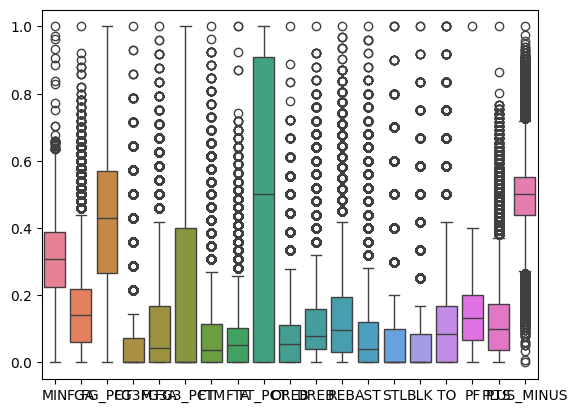

In [ ]:
sns.boxplot(data=data_minmax_scaled)

<Axes: >

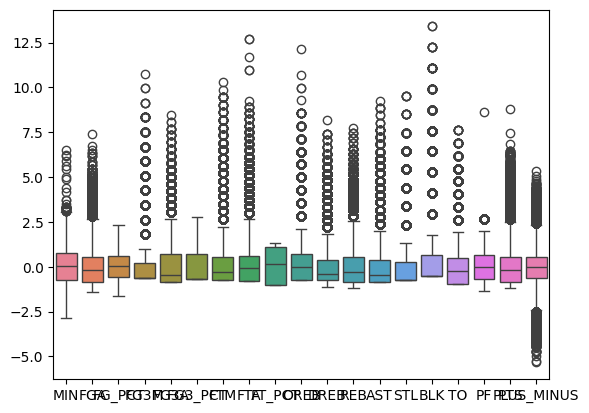

In [ ]:
sns.boxplot(data=data_standard_scaled)

In [ ]:
## splitting data
from sklearn.model_selection import train_test_split

y = data['PLUS_MINUS']
x = data.drop('PLUS_MINUS', axis = 1)
y_minmax_scaled = data_minmax_scaled['PLUS_MINUS']
x_minmax_scaled = data_minmax_scaled.drop('PLUS_MINUS', axis = 1)
y_standard_scaled = data_standard_scaled['PLUS_MINUS']
x_standard_scaled = data_standard_scaled.drop('PLUS_MINUS', axis = 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_minmax_scaled_train, x_minmax_scaled_test, y_minmax_scaled_train, y_minmax_scaled_test = train_test_split(x_minmax_scaled, y_minmax_scaled, test_size = 0.2, random_state = 42)
x_standard_scaled_train, x_standard_scaled_test, y_standard_scaled_train, y_standard_scaled_test = train_test_split(x_standard_scaled, y_standard_scaled, test_size = 0.2, random_state = 42)

In [ ]:
## selecting randomly only 10% of the train data

train_size = int(0.02 * len(x_train))
indices = np.random.choice(x_train.index, train_size, replace=False)
x_train_sample = x_train.loc[indices]
y_train_sample = y_train.loc[indices]

train_size = int(0.02 * len(x_minmax_scaled_train))
indices = np.random.choice(x_minmax_scaled_train.index, train_size, replace=False)
x_minmax_scaled_train_sample = x_minmax_scaled_train.loc[indices]
y_minmax_scaled_train_sample = y_minmax_scaled_train.loc[indices]

train_size = int(0.02 * len(x_standard_scaled_train))
indices = np.random.choice(x_standard_scaled_train.index, train_size, replace=False)
x_standard_scaled_train_sample = x_standard_scaled_train.loc[indices]
y_standard_scaled_train_sample = y_standard_scaled_train.loc[indices]

In [ ]:
train_size

8564

In [ ]:
## applying dummy regressor as baseline model to all types of data
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(x_train, y_train)
dummy_pred = dummy_reg.predict(x_test)
mse_dummy = mean_squared_error(y_test, dummy_pred)

dummy_minmax_scaled_reg = DummyRegressor(strategy='mean')
dummy_minmax_scaled_reg.fit(x_minmax_scaled_train, y_minmax_scaled_train)
dummy_minmax_scaled_pred = dummy_minmax_scaled_reg.predict(x_minmax_scaled_test)
mse_dummy_minmax_scaled = mean_squared_error(y_minmax_scaled_test, dummy_minmax_scaled_pred)

dummy_standard_scaled_reg = DummyRegressor(strategy='mean')
dummy_standard_scaled_reg.fit(x_standard_scaled_train, y_standard_scaled_train)
dummy_standard_scaled_pred = dummy_standard_scaled_reg.predict(x_standard_scaled_test)
mse_dummy_standard_scaled = mean_squared_error(y_standard_scaled_test, dummy_standard_scaled_pred)

dummy_reg_scores = [mse_dummy, mse_dummy_minmax_scaled, mse_dummy_standard_scaled]

## applying linear regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
lin_reg_pred = lin_reg.predict(x_test)
mse_lin_reg = mean_squared_error(y_test, lin_reg_pred)

lin_reg_minmax_scaled = LinearRegression()
lin_reg_minmax_scaled.fit(x_minmax_scaled_train, y_minmax_scaled_train)
lin_reg_minmax_scaled_pred = lin_reg_minmax_scaled.predict(x_minmax_scaled_test)
mse_lin_reg_minmax_scaled = mean_squared_error(y_minmax_scaled_test, lin_reg_minmax_scaled_pred)

lin_reg_standard_scaled = LinearRegression()
lin_reg_standard_scaled.fit(x_standard_scaled_train, y_standard_scaled_train)
lin_reg_standard_scaled_pred = lin_reg_standard_scaled.predict(x_standard_scaled_test)
mse_lin_reg_standard_scaled = mean_squared_error(y_standard_scaled_test, lin_reg_standard_scaled_pred)

lin_reg_scores = [mse_lin_reg, mse_lin_reg_minmax_scaled, mse_lin_reg_standard_scaled]

## applying random_forest on sample data
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor()
rf_reg.fit(x_train_sample, y_train_sample)
rf_reg_pred = rf_reg.predict(x_test)
mse_rf_reg = mean_squared_error(y_test, rf_reg_pred)

rf_reg_minmax_scaled = RandomForestRegressor()
rf_reg_minmax_scaled.fit(x_minmax_scaled_train_sample, y_minmax_scaled_train_sample)
rf_reg_minmax_scaled_pred = rf_reg_minmax_scaled.predict(x_minmax_scaled_test)
mse_rf_reg_minmax_scaled = mean_squared_error(y_minmax_scaled_test, rf_reg_minmax_scaled_pred)

rf_reg_standard_scaled = RandomForestRegressor()
rf_reg_standard_scaled.fit(x_standard_scaled_train_sample, y_standard_scaled_train_sample)
rf_reg_standard_scaled_pred = rf_reg_standard_scaled.predict(x_standard_scaled_test)
mse_rf_reg_standard_scaled = mean_squared_error(y_standard_scaled_test, rf_reg_standard_scaled_pred)

rf_reg_scores = [mse_rf_reg, mse_rf_reg_minmax_scaled, mse_rf_reg_standard_scaled]

## applying knn on sample data
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor()
knn_reg.fit(x_train_sample, y_train_sample)
knn_reg_pred = knn_reg.predict(x_test)
mse_knn_reg = mean_squared_error(y_test, knn_reg_pred)

knn_reg_minmax_scaled = KNeighborsRegressor()
knn_reg_minmax_scaled.fit(x_minmax_scaled_train_sample, y_minmax_scaled_train_sample)
knn_reg_minmax_scaled_pred = knn_reg_minmax_scaled.predict(x_minmax_scaled_test)
mse_knn_reg_minmax_scaled = mean_squared_error(y_minmax_scaled_test, knn_reg_minmax_scaled_pred)

knn_reg_standard_scaled = KNeighborsRegressor()
knn_reg_standard_scaled.fit(x_standard_scaled_train_sample, y_standard_scaled_train_sample)
knn_reg_standard_scaled_pred = knn_reg_standard_scaled.predict(x_standard_scaled_test)
mse_knn_reg_standard_scaled = mean_squared_error(y_standard_scaled_test, knn_reg_standard_scaled_pred)

knn_reg_scores = [mse_knn_reg, mse_knn_reg_minmax_scaled, mse_knn_reg_standard_scaled]

## applying svm
from sklearn.svm import SVR

svm_reg = SVR()
svm_reg.fit(x_train_sample, y_train_sample)
svm_reg_pred = svm_reg.predict(x_test)
mse_svm_reg = mean_squared_error(y_test, svm_reg_pred)

svm_reg_minmax_scaled = SVR()
svm_reg_minmax_scaled.fit(x_minmax_scaled_train_sample, y_minmax_scaled_train_sample)
svm_reg_minmax_scaled_pred = svm_reg_minmax_scaled.predict(x_minmax_scaled_test)
mse_svm_reg_minmax_scaled = mean_squared_error(y_minmax_scaled_test, svm_reg_minmax_scaled_pred)

svm_reg_standard_scaled = SVR()
svm_reg_standard_scaled.fit(x_standard_scaled_train_sample, y_standard_scaled_train_sample)
svm_reg_standard_scaled_pred = svm_reg_standard_scaled.predict(x_standard_scaled_test)
mse_svm_reg_standard_scaled = mean_squared_error(y_standard_scaled_test, svm_reg_standard_scaled_pred)

svm_reg_scores = [mse_svm_reg, mse_svm_reg_minmax_scaled, mse_svm_reg_standard_scaled]

dummy_reg_scores, lin_reg_scores, rf_reg_scores, knn_reg_scores, svm_reg_scores

([113.2098069824275, 0.008711127037736802, 0.9952140758628877],
 [96.88503927155908, 0.007454989171403437, 0.8517049661479492],
 [102.08859269720986, 0.007850060020193323, 0.8971031307184124],
 [118.38422096846509, 0.009156198958519777, 1.0519054667068006],
 [97.54676147357023, 0.00782379993942878, 0.8815522438207998])

In [ ]:
dummy_reg_scores, lin_reg_scores, rf_reg_scores, knn_reg_scores, svm_reg_scores

([113.2098069824275, 0.008711127037736802, 0.9952140758628877],
 [96.88503927155908, 0.007454989171403437, 0.8517049661479492],
 [102.08859269720986, 0.007850060020193323, 0.8971031307184124],
 [118.38422096846509, 0.009156198958519777, 1.0519054667068006],
 [97.54676147357023, 0.00782379993942878, 0.8815522438207998])

In [ ]:
## optimizing svm
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'epsilon': [0.01, 0.1, 1],
              'gamma': ['scale', 0.1, 1, 10],
              'kernel': ['linear', 'rbf', 'poly']}

svm_reg = SVR()
grid_search = GridSearchCV(svm_reg, param_grid, cv=2, scoring='neg_mean_squared_error')
grid_search.fit(x_train_sample, y_train_sample)
grid_search.best_params_